<a href="https://colab.research.google.com/github/dixondanty/AI-ML-internship/blob/main/day5/practice_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv("/content/Teen_Mental_Health_Dataset.csv")

In [5]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [ ]:
df.shape

(1200, 13)

In [ ]:
df.duplicated().value_counts()

,count
False,1200


In [ ]:
df.isnull().value_counts()

,,,,,,,,,,,,,count
age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,
False,False,False,False,False,False,False,False,False,False,False,False,False,1200


In [ ]:
df = df.drop('depression_label', axis=1)

In [ ]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5


In [ ]:
genderc=df['gender'].value_counts()
print("Gender Counts:\n",genderc)

Gender Counts:
 gender
male      615
female    585
Name: count, dtype: int64


In [ ]:
interl=df.groupby(['gender','social_interaction_level']).size()
print("Social interaction by gender:\n",interl)

Social interaction by gender:
 gender  social_interaction_level
female  high                        191
        low                         196
        medium                      197
male    high                        177
        low                         218
        medium                      219
dtype: int64


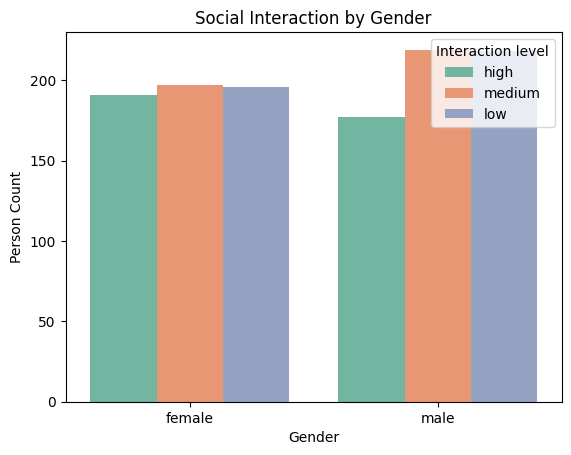

In [ ]:
sns.countplot(x='gender', hue='social_interaction_level', data=df, palette='Set2')
plt.title('Social Interaction by Gender')
plt.xlabel('Gender')
plt.ylabel('Person Count')
plt.legend(title='Interaction level')
plt.show()

In [ ]:
platformc=df['platform_usage'].value_counts()
print("platform usage:\n",platformc)

platform usage:
 platform_usage
Instagram    410
TikTok       397
Both         391
Name: count, dtype: int64


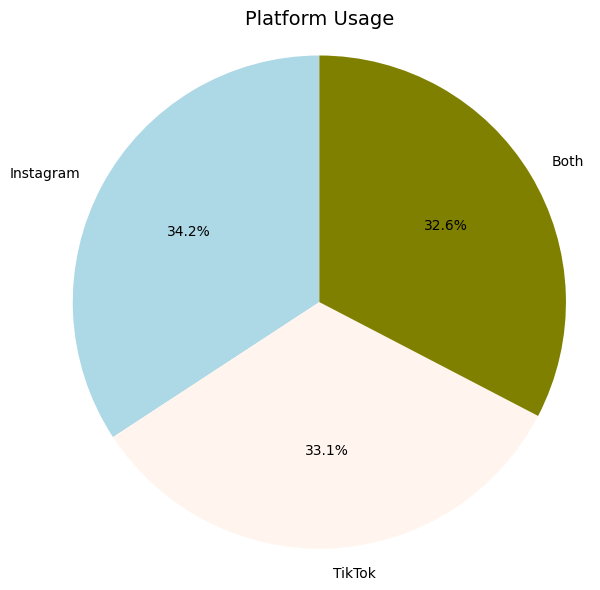

In [ ]:
labels = ['Instagram','TikTok', 'Both']

# Plotting the pie chart
plt.figure(figsize=(7, 7))
plt.pie(platformc, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'seashell', 'olive'])
plt.title('Platform Usage', fontsize=14)
plt.axis('equal')
plt.show()

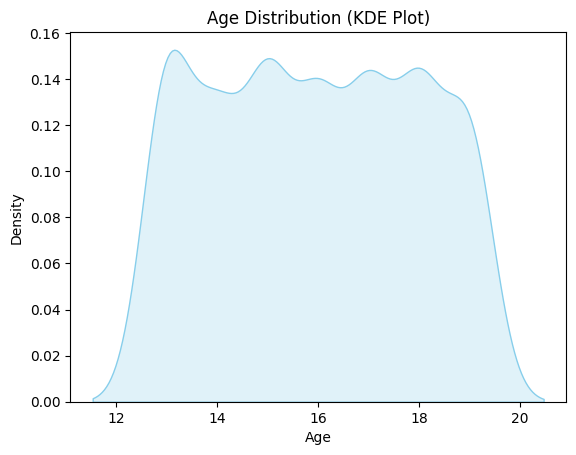

In [ ]:
sns.kdeplot(df['age'], fill=True, color='skyblue')
plt.title('Age Distribution (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

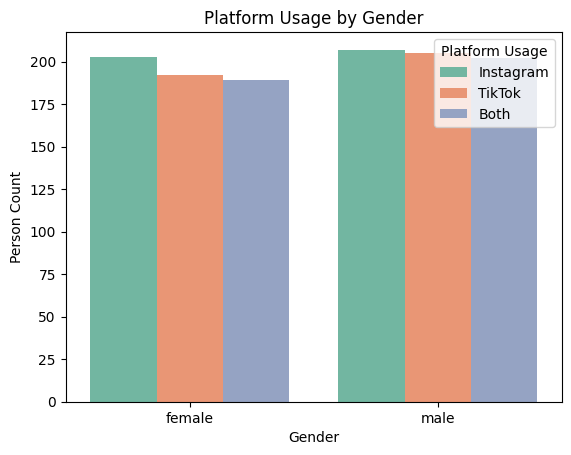

In [ ]:
sns.countplot(x='gender', hue='platform_usage', data=df, palette='Set2')
plt.title('Platform Usage by Gender')
plt.xlabel('Gender')
plt.ylabel('Person Count')
plt.legend(title='Platform Usage')
plt.show()

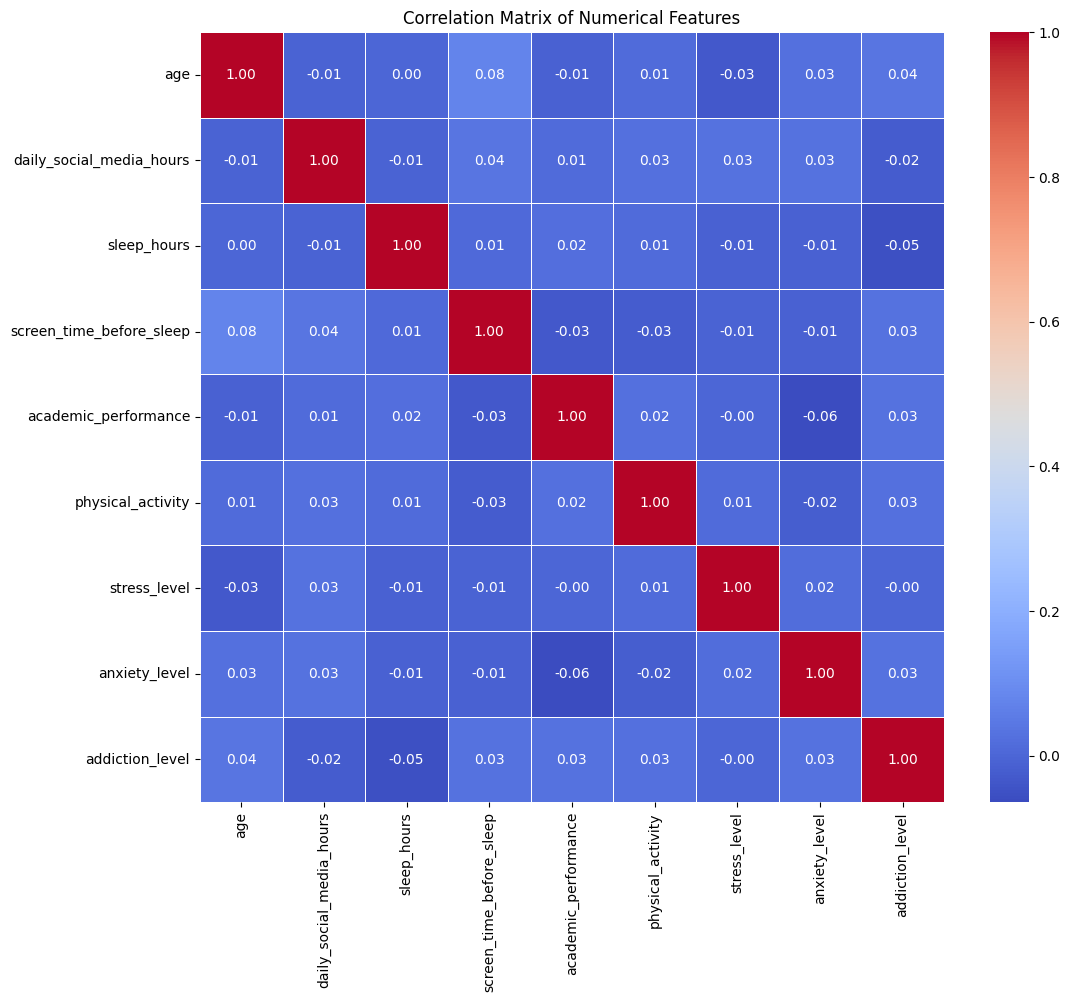

In [33]:
numerical_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

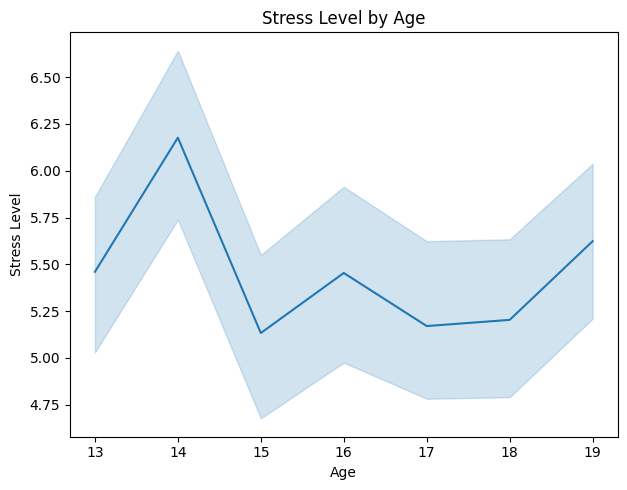

In [37]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
sns.lineplot(x='age', y='stress_level', data=df)
plt.title('Stress Level by Age')
plt.xlabel('Age')
plt.ylabel('Stress Level')

plt.tight_layout()
plt.show()

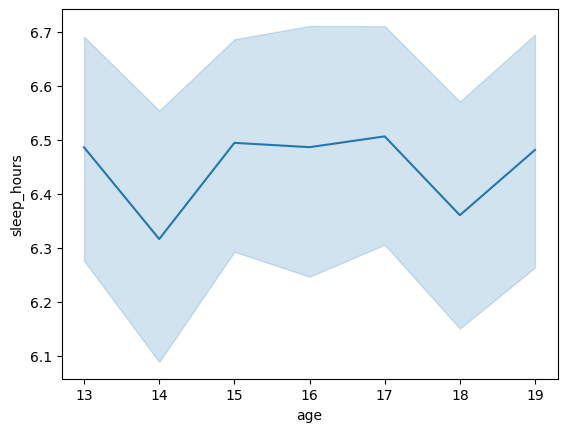

In [9]:
sns.lineplot(x=df['age'], y=df['sleep_hours'])
plt.show()

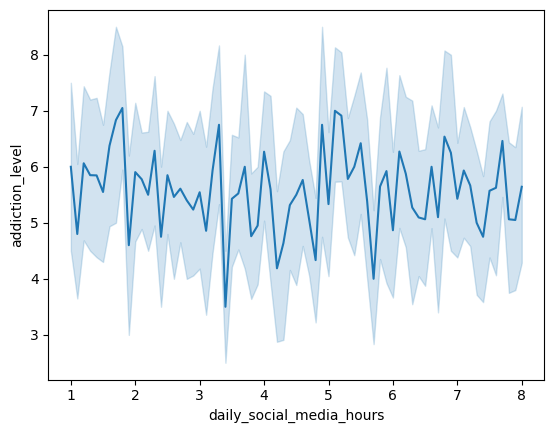

<Figure size 700x1200 with 0 Axes>

In [22]:
sns.lineplot(x=df['daily_social_media_hours'], y=df['addiction_level'])
plt.figure(figsize=(7, 12))
plt.show()

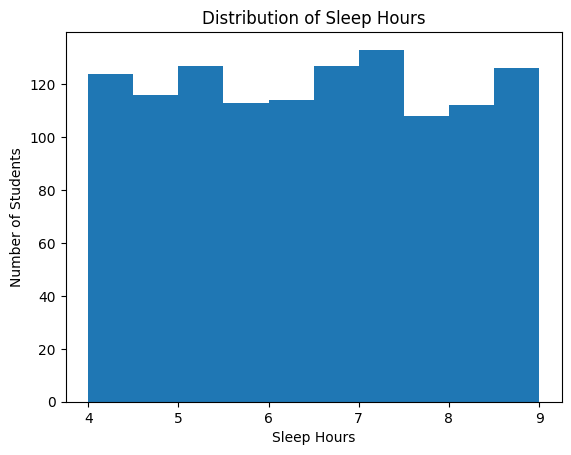

In [43]:
plt.hist(df['sleep_hours'], bins=10)

plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Number of Students")
plt.show()

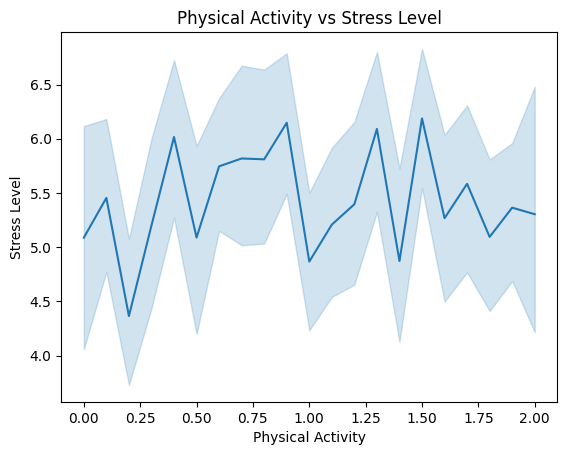

In [41]:
sns.lineplot(
    x='physical_activity',
    y='stress_level',
    data=df
)

plt.title("Physical Activity vs Stress Level")
plt.xlabel("Physical Activity")
plt.ylabel("Stress Level")
plt.show()

age
13    5.745000
14    5.202614
15    5.283333
16    5.411043
17    5.782353
18    5.581395
19    5.907407
Name: addiction_level, dtype: float64


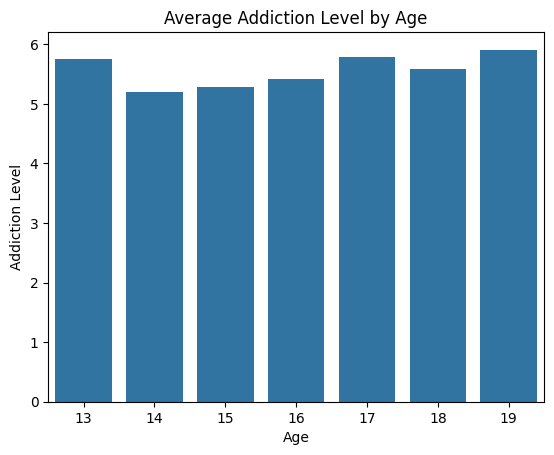

In [42]:
age_addiction = df.groupby('age')['addiction_level'].mean()

print(age_addiction)

sns.barplot(
    x=age_addiction.index,
    y=age_addiction.values
)

plt.title("Average Addiction Level by Age")
plt.xlabel("Age")
plt.ylabel("Addiction Level")
plt.show()

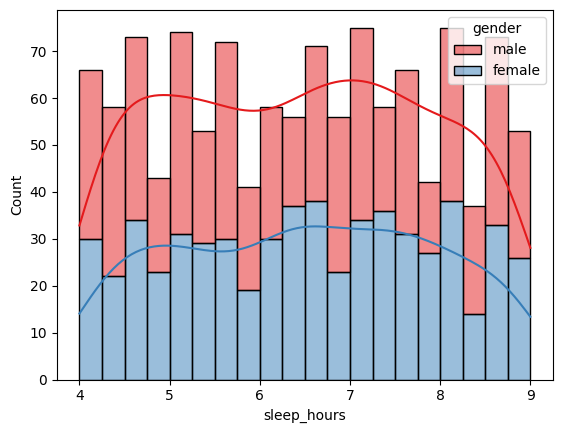

In [11]:
sns.histplot(data=df, x='sleep_hours', hue='gender', multiple='stack', bins=20, palette='Set1',kde=True)
plt.show()